# Heritability processing + plotting CONGRADS

In [40]:
import pandas as pd
import numpy as np
import glob
import os
#import ptitprince as pt
import re
import matplotlib.pyplot as plt
#from nilearn import plotting, image
from matplotlib import cm
import seaborn as sns
import matplotlib.pyplot as plt

base_path = "/data/clusterfs/lag/users/jitame/CONGRADS/"

workspace_path = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/"

In [2]:
def get_file_names_old(gcta_path):
    rois = ["lifg", "lstg", "rifg", "rstg"]
    #roi_rmtg_grad_1_gcta_6tsms_N23204.tsv_resid_norm_N23181.tsv_9.hsq
    var_names = ["roi_{0}_grad_{1}".format(roi, x) for roi in rois for x in range(2)]
    file_names = [os.path.join(gcta_path, x+"_gcta_*.hsq") for x in var_names]   
    return file_names, var_names

def get_file_names(fn):
    return sorted(glob.glob(fn.format("*")))
    
def get_var_names(fn):
    df = pd.read_csv(fn, sep=" |\t", nrows=2)
    return df.columns[2:]

def get_var_numbers(fn_list):
    return [int(os.path.splitext(x)[0].split("_")[-1]) for x in fn_list]

def get_files(fn, no_files):
    
    print("{0} files missing, {1} present".format(no_files - len(fns), len(fns)))
    return fns

def read_h2(data, fn, var_name):
    try:
        #load h2 data
        in_data = pd.read_csv(fn, sep="\t", float_precision='high')
        
        #add to dataframe
        data.loc[var_name, "Vg"] = in_data["Variance"][0]
        data.loc[var_name, "Vg_SE"] = in_data["SE"][0]
        data.loc[var_name, "Ve"] = in_data["Variance"][1]
        data.loc[var_name, "Ve_SE"] = in_data["SE"][1]
        data.loc[var_name, "logL"] = in_data["Variance"][4]
        data.loc[var_name, "P"] = in_data["Variance"][8]
        
    except FileNotFoundError:
        print("{} not found".format(fn))
            
    return data
    
def load_all_h2s(fn, var_names):
    

    data = pd.DataFrame(index=var_names, columns=["Vg", "Vg_SE", "Ve", "Ve_SE", "logL", "P"], dtype=np.float64)
    
    print("Reading h2")
    for i in range(len(var_names)):
        n=i+1
        data = read_h2(data, fn.format(n), var_names[i])

    return data

def to_list(in_list, fn):
    with open(fn, "w") as file:
        for row in in_list:
            file.write(str(row)+'\n')

In [3]:
#to do:
#get files that are run
#get var names from pheno file
#get numbers from filenames hsq
#use numbers to get correct var names
#add to df


In [4]:
del h2_data

NameError: name 'h2_data' is not defined

In [6]:
fn_hsq = os.path.join(base_path, "geno", "gcta", "congrads_{}.hsq")
fns = get_file_names(fn_hsq)
var_names = get_var_names(os.path.join(base_path, "pheno", "all_idps_congrads_new.tsv"))
h2_data = load_all_h2s(fn = fn_hsq, 
                            var_names = var_names)

#var_names = ["{}_AICHA".format(x) for x in get_var_names(os.path.join(base_path, "pheno", "congrads_AICHA_fslcc_pca_g0g1_N49259.tsv")) ]
#h2_data_pcs_AICHA = load_all_h2s(fn = os.path.join(base_path, "geno", "gcta", "congrads_pcs_AICHA_{}.hsq"), 
#                            var_names = var_names)

#var_names = ["{}_GLASSER".format(x) for x in get_var_names(os.path.join(base_path, "pheno", "congrads_glasser_fslcc_pca_g0g1_N49257.tsv")) ]
#h2_data_pcs_GLASSER = load_all_h2s(fn = os.path.join(base_path, "geno", "gcta", "congrads_pcs_glasser_{}.hsq"), 
#                            var_names = var_names)

#h2_data = pd.concat([h2_data_pcs_GLASSER, h2_data, h2_data_pcs_AICHA], axis=0)
#h2_data.drop_duplicates(inplace=True)

/tmp/ipykernel_22898/696078981.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(fn, sep=" |\t", nrows=2)


Reading h2


In [7]:
h2_data["atlas"] = ""
h2_data["idp_type"] = ""
h2_data["g"] = ""
h2_data["roi"] = ""

for idp_nm in h2_data.index:    
    for atlas in ["AICHA", "GLASSER"]:
        if atlas in idp_nm:
            h2_data.loc[idp_nm, "atlas"] = atlas
            
    if "lifg" in idp_nm:
        h2_data.loc[idp_nm, "roi"] = "lifg"
    elif "lstg" in idp_nm:
        h2_data.loc[idp_nm, "roi"] = "lstg"
    elif "lmtg" in idp_nm:
        h2_data.loc[idp_nm, "roi"] = "lstg"

    for g in ["g1", "g2"]:
        if g in idp_nm:
            h2_data.loc[idp_nm, "g"] = g
    
    if "tc" in idp_nm:
        h2_data.loc[idp_nm, "idp_type"] = "TCS"
    elif "pc0" in idp_nm or "pc1" in idp_nm or "pc2" in idp_nm:
        h2_data.loc[idp_nm, "idp_type"] = "TCS_pc"
        
    for roi in ["lstg", "lifg", "lmtg"]:
        if "cmap_{}_oic".format(roi) in idp_nm:
            h2_data.loc[idp_nm, "idp_type"] = "roi_melodic_ic"
        elif "pmap_{}_oic".format(roi) in idp_nm:
            h2_data.loc[idp_nm, "idp_type"] = "whole_brain_melodic_ic"
        elif "cmap_{}_pc".format(roi) in idp_nm:
            h2_data.loc[idp_nm, "idp_type"] = "roi_melodic_pc"
        elif "pmap_{}_pc".format(roi) in idp_nm:
            h2_data.loc[idp_nm, "idp_type"] = "whole_brain_melodic_pc"   

h2_data["sig"] = h2_data["P"] < 0.05/len(h2_data)

In [8]:
h2_data.sort_values(by="Vg", ascending=False, inplace=True)
h2_data.to_csv(os.path.join(workspace_path, "results", "heritability_df_final.tsv"), sep="\t")

In [9]:
h2_data.head(n=25)

,Vg,Vg_SE,Ve,Ve_SE,logL,P,atlas,idp_type,g,roi,sig
melodic_g1_pmap_lifg_oic_1,0.104226,0.009009,0.893666,0.010264,-22592.101,0.000000e+00,,whole_brain_melodic_ic,g1,lifg,True
melodic_g1_pmap_lifg_pc_1,0.098493,0.008956,0.899269,0.010270,-22597.738,0.000000e+00,,whole_brain_melodic_pc,g1,lifg,True
melodic_g1_pmap_lstg_oic_0,0.094109,0.009022,0.903702,0.010382,-22350.695,0.000000e+00,,whole_brain_melodic_ic,g1,lstg,True
melodic_g1_cmap_lifg_oic_1,0.093554,0.008950,0.905696,0.010314,-22638.890,0.000000e+00,,roi_melodic_ic,g1,lifg,True
melodic_g1_pmap_lstg_pc_2,0.092807,0.008983,0.905063,0.010363,-22353.823,0.000000e+00,,whole_brain_melodic_pc,g1,lstg,True
melodic_g1_pmap_lstg_pc_1,0.083018,0.008852,0.914803,0.010345,-22365.444,0.000000e+00,,whole_brain_melodic_pc,g1,lstg,True
melodic_g2_pmap_lstg_oic_0,0.082591,0.009045,0.915365,0.010564,-21677.524,0.000000e+00,,whole_brain_melodic_ic,g2,lstg,True
melodic_g2_pmap_lifg_oic_1,0.081319,0.008825,0.916599,0.010337,-22385.655,0.000000e+00,,whole_brain_melodic_ic,g2,lifg,True
melodic_g1_pmap_lstg_oic_2,0.081293,0.008808,0.916920,0.010327,-22376.410,0.000000e+00,,whole_brain_melodic_ic,g1,lstg,True
melodic_g2_pmap_lstg_pc_2,0.078099,0.008965,0.919866,0.010541,-21682.823,0.000000e+00,,whole_brain_melodic_pc,g2,lstg,True


In [ ]:
h2_data["sig2"] = h2_data["P"] < 0.05
h2_data[(h2_data["idp_type"] == "roi_melodic_ic") & (h2_data["sig2"])].index.tolist()

In [10]:
sig_her = h2_data[ h2_data["sig"] == True ].copy()

to_list(in_list = sig_her.index.to_list(),
        fn = os.path.join(base_path, "pheno/heritable_phenos.txt"))

to_list(in_list = sig_her.index.to_list(),
        fn = os.path.join(workspace_path, "heritable_phenos.txt"))

sig_her.to_csv(os.path.join(base_path, "geno", "gcta", "sig_hers.tsv"), sep="\t")

In [11]:
def make_it_rain_h2_congrads(data, x, hue, hue_order, title):
       
    fig, ax = plt.subplots(figsize=(10, 4))
    
    pt.RainCloud(y = "Vg",
                x = x,
                data = data,
                orient = "h",
                palette = "colorblind",
                hue = hue,
                hue_order = hue_order,
                bw=.2,
                ax = ax,
                move=0.25,
                width_viol = .4)
    
        #change axes
    ax.set_xlim([-.001, .1])
        
    ax.set_xlabel("Heritability")
    ax.set_ylabel("IDP category")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[0:3], labels[0:3],
                       bbox_to_anchor=(0.75, 1), loc=2, borderaxespad=0.,
                       title = hue)
    
    fig.suptitle(title)

In [36]:
import numpy as np
import pandas as pd
from scipy import stats

def calculate_meta(h2s, standard_errors):
    """
    Calculate meta-analytic h2-statistic using inverse-variance weighting
    
    Parameters:
    values: array of heritability estimates
    standard_errors: array of corresponding standard errors
    
    Returns:
    meta_h2: weighted average z-statistic
    meta_se: standard error of the meta-analytic estimate
    """
    
    # Calculate weights (inverse variance)
    weights = 1 / (standard_errors ** 2)
    
    # Meta-analytic weighted average z-statistic
    meta_h2 = np.sum(weights * h2s) / np.sum(weights)
    
    # Standard error of meta-analytic estimate
    meta_se = 1 / np.sqrt(np.sum(weights))
    
    return meta_h2, meta_se

# Apply to your data by category

meta_results = []

for g in ["g1", "g2"]:
    in_data = h2_data[h2_data["g"] == g]
    #for atlas in  ["GLASSER", "AICHA"]:
        #data = in_data[in_data["atlas"] == atlas]
    for category in h2_data['idp_type'].dropna().unique():
        category_data = in_data[in_data['idp_type'] == category]

        if len(category_data) > 0:
            meta_h2, meta_se = calculate_meta(
                    category_data['Vg'].values, 
                    category_data['Vg_SE'].values
                )

            meta_results.append({
                    'category': category+"_"+atlas+"_"+g,
                    'n_observations': len(category_data),
                    'meta_h2': meta_h2,
                    'meta_se': meta_se,
                    'mean_h2': np.mean(category_data['Vg']),
                })

meta_df = pd.DataFrame(meta_results)
#print(meta_df.head())
meta_df.sort_values(by="meta_h2", ascending=False, inplace=True)
meta_df.to_csv(os.path.join(workspace_path, "results", "meta_h2_df_final_new.tsv"), sep="\t", index=False)

In [31]:
meta_df.head()

,category,n_observations,meta_h2,meta_se,mean_h2
0,whole_brain_melodic_ic_g1,6,0.069448,0.003524,0.071304
1,whole_brain_melodic_pc_g1,6,0.062700,0.003483,0.066137
6,whole_brain_melodic_ic_g2,6,0.052718,0.003462,0.055068
7,whole_brain_melodic_pc_g2,6,0.047674,0.003436,0.050032
2,roi_melodic_ic_g1,6,0.041380,0.003346,0.043489


In [32]:
import pandas as pd
import numpy as np
import glob
import os
#import ptitprince as pt
import re
import matplotlib.pyplot as plt
#from nilearn import plotting, image
from matplotlib import cm
import seaborn as sns
import matplotlib.pyplot as plt

workspace_path = r"P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest"

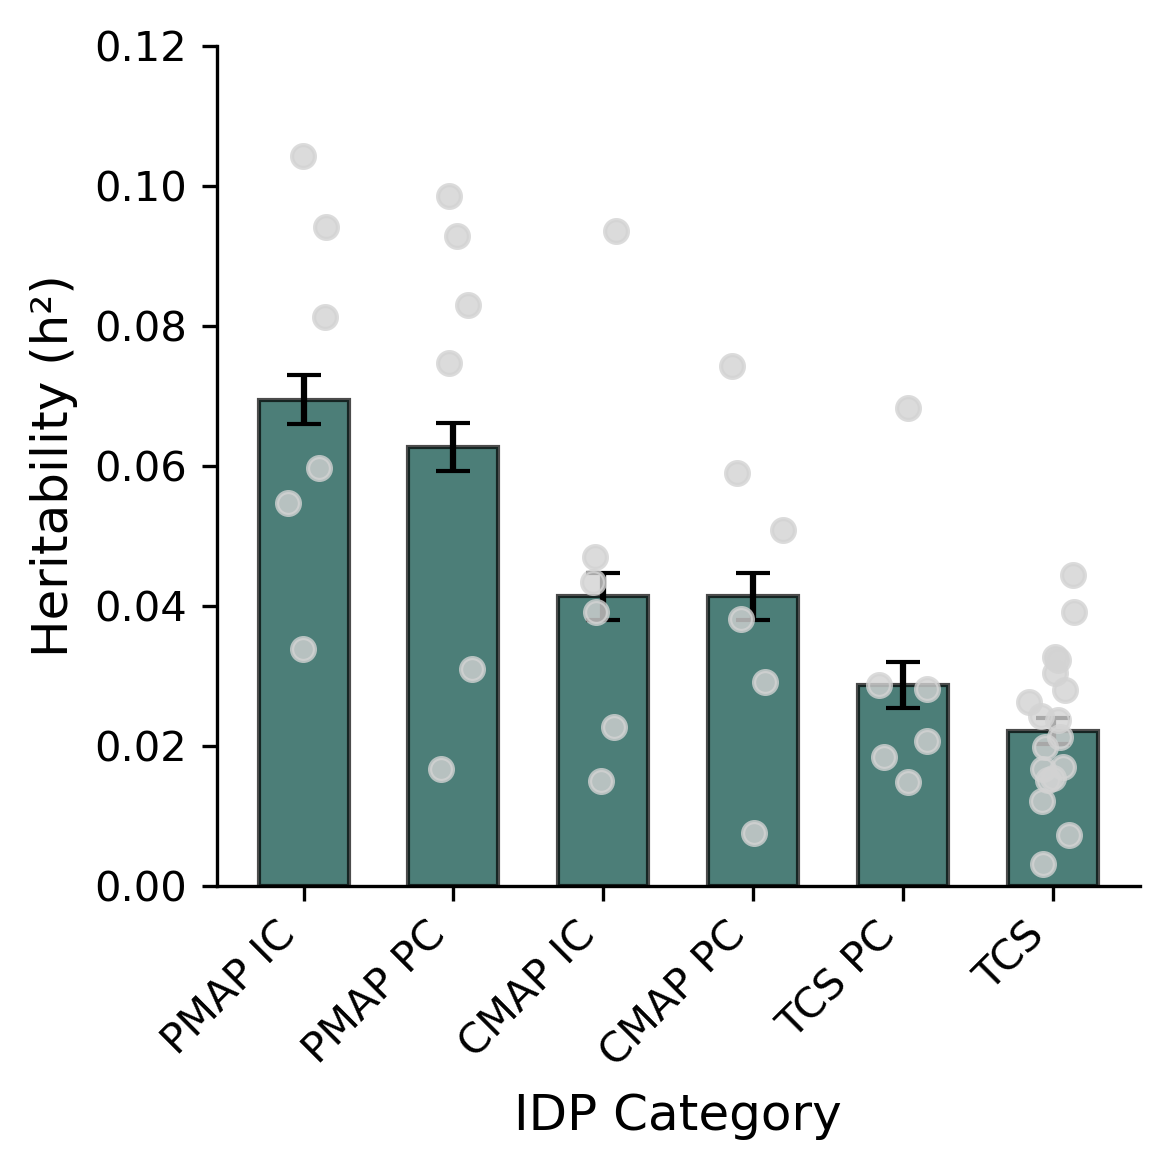

In [37]:
meta_df = pd.read_csv(os.path.join(workspace_path, "results", "meta_h2_df_final_new.tsv"), sep="\t")
h2_data = pd.read_csv(os.path.join(workspace_path, "results", "heritability_df_final.tsv"), sep="\t")

atlas = "GLASSER"
g = "g1"

plot_df = meta_df[(meta_df["category"].str.contains(atlas)) & (meta_df["category"].str.contains(g))]
colors = ['#00483F']
#colors = [ "#AA1926", "#00786A", "#214D9D"]
colors_overlay = [ "lightgrey", "grey"] #['#F7B682'] 
palette = sns.color_palette(colors)
palette_overlay = sns.color_palette(colors_overlay)

# Extract category names without atlas and gradient info for cleaner labels
plot_df = plot_df.copy()
plot_df['clean_category'] = plot_df['category'].str.replace(f'_{atlas}_{g}', '')

# Create the bar plot with error bars and individual points
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

# Bar plot with error bars
bars = ax.bar(range(len(plot_df)), 
              plot_df['meta_h2'], 
              yerr=plot_df['meta_se'],
              capsize=4,
              color=palette[0],
              edgecolor='black',
              linewidth=1,
              width=0.6,
              alpha=0.7,
              label='Meta-analytic weighted mean')

# Overlay individual data points
for i, category in enumerate(plot_df['clean_category']):
    # Get individual data points for this category
    individual_data = h2_data[(h2_data['idp_type'] == category) & 
                              (h2_data['g'] == g)]
                             #(h2_data['atlas'] == atlas) & 
                             
    
    if len(individual_data) > 0:
        # Add jitter to x positions for better visibility
        x_positions = np.random.normal(i, 0.1, len(individual_data))
        ax.scatter(x_positions, 
                  individual_data['Vg'], 
                  color=palette_overlay[0], 
                  alpha=0.8, 
                  s=30,
                  zorder=3,
                  label='Individual estimates' if i == 0 else "")

# Customize the plot
ax.set_xlabel('IDP Category', fontsize=12)
ax.set_ylabel('Heritability (h²)',fontsize=12)
ax.set_ylim(0, 0.12)
#ax.set_title('Meta-analytic h²')

# Set x-axis labels
ax.set_xticks(range(len(plot_df)))
labels=["PMAP IC", "PMAP PC", "CMAP IC", "CMAP PC", "TCS PC", "TCS"]
ax.set_xticklabels(labels, rotation=45, ha='right', size=10)

# Style the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "results", f"meta_h2_barplot_with_individuals_{atlas}_{g}.png"), 
            bbox_inches="tight", dpi=300)
plt.show()

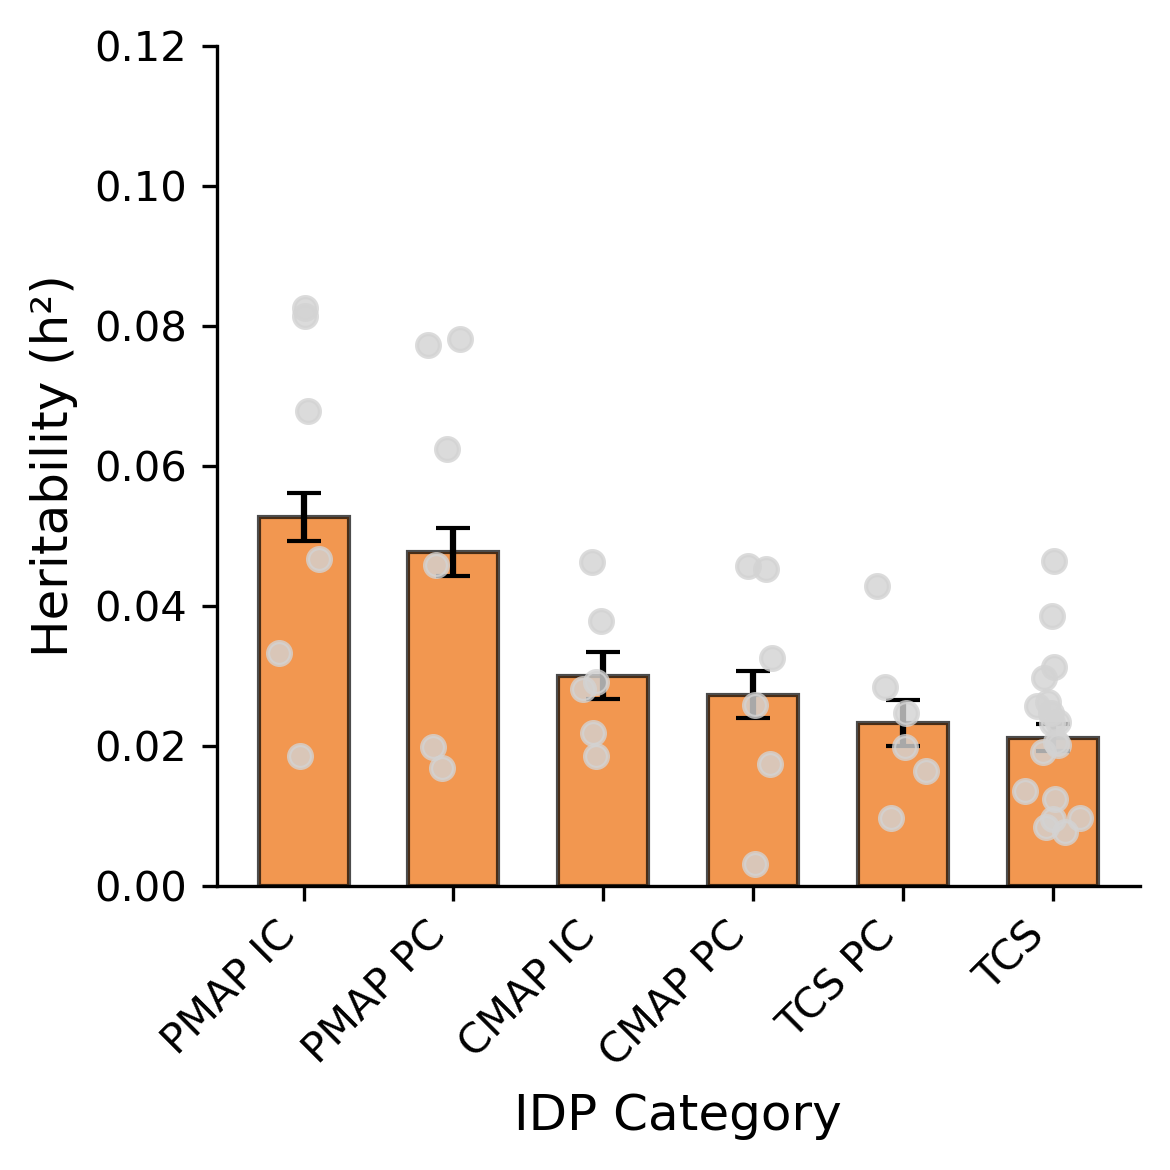

In [45]:
meta_df = pd.read_csv(os.path.join(workspace_path, "results", "meta_h2_df_final_new.tsv"), sep="\t")
h2_data = pd.read_csv(os.path.join(workspace_path, "results", "heritability_df_final.tsv"), sep="\t")

atlas = "GLASSER"
g = "g2"

plot_df = meta_df[(meta_df["category"].str.contains(atlas)) & (meta_df["category"].str.contains(g))]
colors = ["#ED6B06"]
#colors = [ "#AA1926", "#00786A", "#214D9D"]
colors_overlay = [ "lightgrey", "grey"] #['#F7B682'] 
palette = sns.color_palette(colors)
palette_overlay = sns.color_palette(colors_overlay)

# Extract category names without atlas and gradient info for cleaner labels
plot_df = plot_df.copy()
plot_df['clean_category'] = plot_df['category'].str.replace(f'_{atlas}_{g}', '')

# Create the bar plot with error bars and individual points
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

# Bar plot with error bars
bars = ax.bar(range(len(plot_df)), 
              plot_df['meta_h2'], 
              yerr=plot_df['meta_se'],
              capsize=4,
              color=palette[0],
              edgecolor='black',
              linewidth=1,
              width=0.6,
              alpha=0.7,
              label='Meta-analytic weighted mean')

# Overlay individual data points
for i, category in enumerate(plot_df['clean_category']):
    # Get individual data points for this category
    individual_data = h2_data[(h2_data['idp_type'] == category) & 
                              (h2_data['g'] == g)]
                             #(h2_data['atlas'] == atlas) & 
                             
    
    if len(individual_data) > 0:
        # Add jitter to x positions for better visibility
        x_positions = np.random.normal(i, 0.1, len(individual_data))
        ax.scatter(x_positions, 
                  individual_data['Vg'], 
                  color=palette_overlay[0], 
                  alpha=0.8, 
                  s=30,
                  zorder=3,
                  label='Individual estimates' if i == 0 else "")

# Customize the plot
ax.set_xlabel('IDP Category', fontsize=12)
ax.set_ylabel('Heritability (h²)',fontsize=12)
ax.set_ylim(0, 0.12)
#ax.set_title('Meta-analytic h²')

# Set x-axis labels
ax.set_xticks(range(len(plot_df)))
labels=["PMAP IC", "PMAP PC", "CMAP IC", "CMAP PC", "TCS PC", "TCS"]
ax.set_xticklabels(labels, rotation=45, ha='right', size=10)

# Style the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "results", f"meta_h2_barplot_with_individuals_{atlas}_{g}.png"), 
            bbox_inches="tight", dpi=300)
plt.show()